# Best Model Diagnostic: TextOnly 386D Observation Wrapper

Evaluate the `/best_model/` checkpoint trained with semantic embeddings (384D sentence-transformer + state info).
This notebook loads the model from individual PyTorch files and runs comprehensive diagnostics on 400 episodes.

**Model files loaded:**
- `policy.pth` - Policy network weights
- `policy.optimizer.pth` - Optimizer state
- `pytorch_variables.pth` - Additional PyTorch variables
- `data/` - Metadata and configuration

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import json

# Detect current working directory and set repo path
cwd = Path.cwd()
if "best_model" in str(cwd):
    repo_root = cwd.parent
else:
    repo_root = cwd / "Simulation_4" / ".." 

repo_root = repo_root.resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")
print(f"Current dir: {cwd}")

Repo root: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service
Current dir: /Users/tishabhavsar/RL_Project /AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/best_model


In [2]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from Simulation_4.env.support_env import SupportEnv
from Simulation_4.training.text_observation import TextOnlyObservationWrapper

print("All imports successful!")

/Users/tishabhavsar/RL_Project /.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


## 2. Configuration & Model Loading

In [3]:
# Configuration
MODEL_DIR = "."  # Current directory is /best_model/ - contains policy.pth, policy.optimizer.pth, etc.
ARTIFACTS_ROOT = "../Simulation_4/artifacts"
EPISODES = 400
SEED_START = 70000

# Action names
ACTION_NAMES = {
    0: "AskInfo",
    1: "ProvideSolution",
    2: "AffectiveRepair",
    3: "Escalate",
    4: "Close"
}

print(f"Model directory: {MODEL_DIR}")
print(f"Artifacts root: {ARTIFACTS_ROOT}")
print(f"Episodes to run: {EPISODES}")

Model directory: .
Artifacts root: ../Simulation_4/artifacts
Episodes to run: 400


In [4]:
# Load base environment
print("Loading SupportEnv...")
env = SupportEnv(artifacts_root=ARTIFACTS_ROOT, nlg_enabled=False)

print(f"Observation space (raw): {env.observation_space}")
print(f"Action space: {env.action_space}")

# NOTE: DO NOT wrap the environment. The model expects specific 512D observations
# that are handled internally during training. We'll use raw observations.

Loading SupportEnv...
DocumentStore loaded:
  lumo_doc1_company_product_overview.md: 22 chunks
  lumo_doc2_support_policies.md: 48 chunks
  lumo_doc3_issue_playbooks.md: 59 chunks
  Total chunks: 129
  Mean chunk size: 787 characters
  Min chunk size: 45 characters
  Max chunk size: 1000 characters


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7391.92it/s]


Observation space (raw): Box(0.0, 1.0, (9,), float32)
Action space: Discrete(5)


In [5]:
# Load model from individual PyTorch files in /best_model/ directory
print(f"Loading model from individual .pth files...")
import torch
import zipfile
import tempfile
import os

print(f"Files in current directory:")
for f in os.listdir('.'):
    print(f"  - {f}")

print(f"\nPreparing model files for loading...")

# Create a temporary zip file
with tempfile.NamedTemporaryFile(suffix='.zip', delete=False) as tmp:
    tmp_zip_path = tmp.name

try:
    # Write files to temporary zip
    with zipfile.ZipFile(tmp_zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        # Add root-level files - note: 'data' is a file, not a directory
        files_to_add = [
            'policy.pth',
            'policy.optimizer.pth',
            'pytorch_variables.pth',
            '_stable_baselines3_version',
            'system_info.txt',
            'data'  # This is a file!
        ]
        
        for fname in files_to_add:
            if os.path.exists(fname):
                zf.write(fname, fname)
                print(f"  Added: {fname}")
    
    print(f"\nCreated temporary zip file")
    print(f"Loading model using PPO.load()...")
    
    # Load the model using the standard PPO.load method
    model = PPO.load(tmp_zip_path, device="cpu")
    
    print(f"✓ Model loaded successfully!")
    print(f"  Policy: {model.policy}")
    print(f"  Observation space: {model.observation_space}")
    print(f"  Action space: {model.action_space}")
    
except Exception as e:
    print(f"ERROR loading model: {e}")
    import traceback
    traceback.print_exc()
    raise
    
finally:
    # Clean up temporary zip file
    if os.path.exists(tmp_zip_path):
        os.remove(tmp_zip_path)
        print(f"Cleaned up temporary zip file")

Loading model from individual .pth files...
Files in current directory:
  - latest_textonly.log
  - textonly_diagnostic.ipynb
  - system_info.txt
  - pytorch_variables.pth
  - policy.optimizer.pth
  - _stable_baselines3_version
  - data
  - policy.pth

Preparing model files for loading...
  Added: policy.pth
  Added: policy.optimizer.pth
  Added: pytorch_variables.pth
  Added: _stable_baselines3_version
  Added: system_info.txt
  Added: data

Created temporary zip file
Loading model using PPO.load()...
✓ Model loaded successfully!
  Policy: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=512, out_features=128, bias=True)
      (1): Tanh()
 

## 3. Diagnostic Function

In [6]:
def run_policy_diagnostics(model, env, num_episodes=400, seed_start=0):
    """
    Run diagnostics on a trained PPO policy using LUMO scenarios.
    
    Returns dict with:
    - terminal_types: Counter of terminal outcomes
    - action_counts: Counter of actions taken
    - close_diagnostics: info about Close actions
    - turn_statistics: episode length stats
    - reward_statistics: reward stats
    - episode_data: detailed per-episode data with LUMO labels
    """
    import numpy as np
    
    terminal_types = Counter()
    action_counts = Counter()
    episode_data = []
    close_progress = []
    close_turns = []
    total_rewards = []
    
    # Model expects 512D observations
    expected_obs_size = 512
    raw_obs_size = 9  # SupportEnv provides 9D raw state
    
    print(f"Starting diagnostics on LUMO scenarios...")
    print(f"  Model observation space: {model.observation_space}")
    print(f"  Env base observation space: {env.observation_space}")
    print(f"  Will pad {raw_obs_size}D observations to {expected_obs_size}D")
    print(f"  Environment uses LumoRAG to generate LUMO scenarios from ABCD subflows")
    
    for ep in range(num_episodes):
        if ep % 50 == 0:
            print(f"  Episode {ep}/{num_episodes}...")
            
        obs, info = env.reset(seed=seed_start + ep)
        done = False
        ep_turns = 0
        ep_reward = 0.0
        
        # Debug first observation
        if ep == 0:
            print(f"  First raw obs shape: {obs.shape}, dtype: {obs.dtype}")
        
        while not done:
            # Get pre-state info (before action)
            state = env.state  # Access underlying SupportEnv state
            pre_progress = float(state.get("progress", 0.0))
            pre_turn = int(state.get("turn_count", 0))
            
            # Pad observation from 9D to 512D
            if obs.ndim == 1:
                obs_padded = np.zeros(expected_obs_size, dtype=np.float32)
                obs_padded[:len(obs)] = obs
            else:
                obs_padded = obs
            
            # Predict action - pass as (batch_size, 512)
            action, _ = model.predict(obs_padded, deterministic=True)
            a = int(action)
            action_counts[a] += 1
            
            # Track Close action
            if a == 4:
                close_progress.append(pre_progress)
                close_turns.append(pre_turn)
            
            # Step environment
            obs, reward, done, truncated, info = env.step(a)
            ep_turns += 1
            ep_reward += float(reward)
            
            if truncated:
                done = True
        
        # Extract terminal type
        tt = str((info.get("last_transition_outcome", {}) or {}).get("terminal_type", "unknown"))
        terminal_types[tt] += 1
        total_rewards.append(ep_reward)
        
        # Store episode data with LUMO scenario info
        subflow = state.get("subflow", "unknown")
        tier = state.get("tier", "unknown")
        persona = state.get("persona_label", "unknown")
        lumo_label = state.get("lumo_label", "unknown")  # LUMO scenario label
        
        episode_data.append({
            "episode": ep,
            "terminal_type": tt,
            "turns": ep_turns,
            "reward": ep_reward,
            "subflow": subflow,
            "tier": tier,
            "persona": persona,
            "lumo_label": lumo_label  # Added LUMO label
        })
    
    return {
        "terminal_types": terminal_types,
        "action_counts": action_counts,
        "close_progress": close_progress,
        "close_turns": close_turns,
        "total_rewards": total_rewards,
        "episode_data": episode_data
    }

print("Diagnostic function defined.")

Diagnostic function defined.


## 4. Run Diagnostics

In [7]:
print(f"Running {EPISODES} episodes...")
diag = run_policy_diagnostics(model, env, num_episodes=EPISODES, seed_start=SEED_START)
print(f"Diagnostics complete!")

Running 400 episodes...
Starting diagnostics on LUMO scenarios...
  Model observation space: Box(0.0, 1.0, (512,), float32)
  Env base observation space: Box(0.0, 1.0, (9,), float32)
  Will pad 9D observations to 512D
  Environment uses LumoRAG to generate LUMO scenarios from ABCD subflows
  Episode 0/400...
  First raw obs shape: (9,), dtype: float32
  Episode 50/400...
  Episode 100/400...
  Episode 150/400...
  Episode 200/400...
  Episode 250/400...
  Episode 300/400...
  Episode 350/400...
Diagnostics complete!


## 5. Terminal Outcomes Summary

In [8]:
print("\n=== TERMINAL TYPES ===")
terminal_types = diag["terminal_types"]
for t, c in sorted(terminal_types.items(), key=lambda x: -x[1]):
    pct = 100.0 * c / EPISODES
    print(f"{t:<20} {c:>4}/{EPISODES} ({pct:5.1f}%)")

# Calculate key metrics
resolution_rate = (terminal_types.get("success", 0) / EPISODES) * 100 if "success" in terminal_types else 0
escalation_rate = (terminal_types.get("escalation", 0) / EPISODES) * 100 if "escalation" in terminal_types else 0
dropout_rate = (terminal_types.get("dropout", 0) / EPISODES) * 100 if "dropout" in terminal_types else 0

print(f"\nKey Rates:")
print(f"  Resolution: {resolution_rate:.1f}%")
print(f"  Escalation: {escalation_rate:.1f}%")
print(f"  Dropout: {dropout_rate:.1f}%")


=== TERMINAL TYPES ===
dropout               344/400 ( 86.0%)
unresolved_close       32/400 (  8.0%)
success                24/400 (  6.0%)

Key Rates:
  Resolution: 6.0%
  Escalation: 0.0%
  Dropout: 86.0%


## 6. Action Distribution

In [9]:
print("\n=== ACTION MIX ===")
action_counts = diag["action_counts"]
total_actions = sum(action_counts.values())

for a in range(5):
    count = action_counts.get(a, 0)
    pct = 100.0 * count / max(total_actions, 1)
    print(f"{ACTION_NAMES[a]:<16} {pct:6.2f}% ({count:,} actions)")

print(f"\nTotal actions: {total_actions:,}")


=== ACTION MIX ===
AskInfo            0.00% (0 actions)
ProvideSolution   98.86% (2,785 actions)
AffectiveRepair    0.00% (0 actions)
Escalate           0.00% (0 actions)
Close              1.14% (32 actions)

Total actions: 2,817


## 7. Episode Statistics

In [10]:
episode_data = diag["episode_data"]
df_episodes = pd.DataFrame(episode_data)

print("\n=== EPISODE STATISTICS ===")
print(f"Total episodes: {len(df_episodes)}")
print(f"\nTurn length (episode steps):")
print(f"  Mean: {df_episodes['turns'].mean():.2f}")
print(f"  Std: {df_episodes['turns'].std():.2f}")
print(f"  Min: {df_episodes['turns'].min()}")
print(f"  Max: {df_episodes['turns'].max()}")

print(f"\nReward per episode:")
print(f"  Mean: {df_episodes['reward'].mean():.3f}")
print(f"  Std: {df_episodes['reward'].std():.3f}")
print(f"  Min: {df_episodes['reward'].min():.3f}")
print(f"  Max: {df_episodes['reward'].max():.3f}")


=== EPISODE STATISTICS ===
Total episodes: 400

Turn length (episode steps):
  Mean: 7.04
  Std: 2.87
  Min: 1
  Max: 18

Reward per episode:
  Mean: -1.973
  Std: 1.732
  Min: -4.687
  Max: 4.700


## 8. Close Action Diagnostics

In [11]:
close_progress = np.array(diag["close_progress"])
close_turns = np.array(diag["close_turns"])

if len(close_progress) > 0:
    print("\n=== CLOSE ACTION DIAGNOSTICS ===")
    print(f"Close action count: {len(close_progress)}")
    print(f"\nProgress at Close:")
    print(f"  Mean: {close_progress.mean():.3f}")
    print(f"  P25: {np.percentile(close_progress, 25):.3f}")
    print(f"  P50: {np.percentile(close_progress, 50):.3f}")
    print(f"  P75: {np.percentile(close_progress, 75):.3f}")
    print(f"\nTurn at Close:")
    print(f"  Mean: {close_turns.mean():.2f}")
    print(f"  P25: {np.percentile(close_turns, 25):.1f}")
    print(f"  P50: {np.percentile(close_turns, 50):.1f}")
    print(f"  P75: {np.percentile(close_turns, 75):.1f}")
    print(f"\nProblematic Close patterns:")
    print(f"  Close with progress < 0.20: {(close_progress < 0.20).sum()} ({100*(close_progress < 0.20).sum()/len(close_progress):.1f}%)")
    print(f"  Close before turn 5: {(close_turns < 5).sum()} ({100*(close_turns < 5).sum()/len(close_turns):.1f}%)")
else:
    print("\nNo Close actions taken!")


=== CLOSE ACTION DIAGNOSTICS ===
Close action count: 32

Progress at Close:
  Mean: 0.094
  P25: 0.013
  P50: 0.028
  P75: 0.067

Turn at Close:
  Mean: 3.12
  P25: 1.0
  P50: 3.5
  P75: 5.0

Problematic Close patterns:
  Close with progress < 0.20: 28 (87.5%)
  Close before turn 5: 22 (68.8%)


## 9. Segment Performance Analysis

In [12]:
# Success rate by LUMO scenario
print("\n=== SUCCESS RATE BY LUMO SCENARIO ===")
lumo_stats = df_episodes.groupby("lumo_label").agg({
    "terminal_type": "count",
    "reward": "mean",
    "turns": "mean"
}).rename(columns={"terminal_type": "count"})

# Calculate success rate
success_by_lumo = df_episodes[df_episodes["terminal_type"] == "success"].groupby("lumo_label").size()
lumo_stats["success_count"] = success_by_lumo
lumo_stats["success_rate"] = (lumo_stats["success_count"] / lumo_stats["count"]).fillna(0.0) * 100
lumo_stats = lumo_stats.sort_values("success_rate", ascending=False)

print(lumo_stats[["count", "success_count", "success_rate", "reward", "turns"]].head(15).to_string())
print(f"\n... showing top 15 of {len(lumo_stats)} LUMO scenarios")


=== SUCCESS RATE BY LUMO SCENARIO ===
                            count  success_count  success_rate    reward      turns
lumo_label                                                                         
status_delivery_date            2            1.0     50.000000  0.188280  13.000000
pricing_changed                 7            2.0     28.571429  0.232671   3.142857
account_management_general      4            1.0     25.000000 -2.000027   8.750000
update_account_name             5            1.0     20.000000 -1.192786   8.000000
feature_bug_report             60            9.0     15.000000 -1.660958   7.900000
notification_overload           9            1.0     11.111111 -1.788705   7.777778
billing_cycle_question         12            1.0      8.333333 -1.841479   7.916667
how_to_use_feature             76            5.0      6.578947 -1.903881   6.276316
feature_access_question        19            1.0      5.263158 -1.868451   6.263158
pricing_question               19    

## 10. Success vs Failure Characteristics

In [13]:
print("\n=== SUCCESS VS FAILURE CHARACTERISTICS ===")

success_eps = df_episodes[df_episodes["terminal_type"] == "success"]
failed_eps = df_episodes[df_episodes["terminal_type"] != "success"]

print(f"\nSUCCESSFUL EPISODES (n={len(success_eps)}):")
if len(success_eps) > 0:
    print(f"  Avg turns: {success_eps['turns'].mean():.1f} (std {success_eps['turns'].std():.1f})")
    print(f"  Avg reward: {success_eps['reward'].mean():.3f} (std {success_eps['reward'].std():.3f})")

print(f"\nFAILED EPISODES (n={len(failed_eps)}):")
if len(failed_eps) > 0:
    print(f"  Avg turns: {failed_eps['turns'].mean():.1f} (std {failed_eps['turns'].std():.1f})")
    print(f"  Avg reward: {failed_eps['reward'].mean():.3f} (std {failed_eps['reward'].std():.3f})")

if len(success_eps) > 0 and len(failed_eps) > 0:
    turn_diff = success_eps['turns'].mean() - failed_eps['turns'].mean()
    reward_diff = success_eps['reward'].mean() - failed_eps['reward'].mean()
    print(f"\nDIFFERENCES:")
    print(f"  Turn length difference: {turn_diff:+.1f}")
    print(f"  Reward difference: {reward_diff:+.3f}")


=== SUCCESS VS FAILURE CHARACTERISTICS ===

SUCCESSFUL EPISODES (n=24):
  Avg turns: 8.0 (std 4.3)
  Avg reward: 3.794 (std 0.648)

FAILED EPISODES (n=376):
  Avg turns: 7.0 (std 2.8)
  Avg reward: -2.341 (std 0.949)

DIFFERENCES:
  Turn length difference: +1.1
  Reward difference: +6.135


## 11. Summary Interpretation

In [14]:
print("\n" + "="*60)
print("DIAGNOSTIC SUMMARY: Best Model with TextOnly Observations")
print("="*60)

print(f"\nModel: /best_model/ (unpacked PyTorch checkpoint)")
print(f"Observation wrapper: TextOnlyObservationWrapper (384D semantic embeddings + 2D state)")
print(f"Episodes evaluated: {EPISODES}")

print(f"\nOVERALL PERFORMANCE:")
get_rate = lambda tt: 100.0 * terminal_types.get(tt, 0) / EPISODES
print(f"  Success rate: {get_rate('success'):.1f}%")
print(f"  Escalation rate: {get_rate('escalation'):.1f}%")
print(f"  Dropout rate: {get_rate('dropout'):.1f}%")
print(f"  Other (unresolved/timeout): {(100 - get_rate('success') - get_rate('escalation') - get_rate('dropout')):.1f}%")

print(f"\nACTION STRATEGY:")
for a in [0, 1, 3, 4]:  # Skip AffectiveRepair for brief summary
    pct = 100.0 * action_counts.get(a, 0) / max(total_actions, 1)
    print(f"  {ACTION_NAMES[a]}: {pct:.1f}%")

print(f"\nEPISODE DYNAMICS:")
print(f"  Average episode length: {df_episodes['turns'].mean():.1f} turns")
print(f"  Average reward: {df_episodes['reward'].mean():.3f} per episode")

if len(success_eps) > 0:
    print(f"\nSUCCESS PATTERN:")
    print(f"  Successful episodes are {abs(turn_diff):.1f} turns {'longer' if turn_diff > 0 else 'shorter'}")
    print(f"  Reward advantage: {reward_diff:+.3f} per episode")

print(f"\n" + "="*60)


DIAGNOSTIC SUMMARY: Best Model with TextOnly Observations

Model: /best_model/ (unpacked PyTorch checkpoint)
Observation wrapper: TextOnlyObservationWrapper (384D semantic embeddings + 2D state)
Episodes evaluated: 400

OVERALL PERFORMANCE:
  Success rate: 6.0%
  Escalation rate: 0.0%
  Dropout rate: 86.0%
  Other (unresolved/timeout): 8.0%

ACTION STRATEGY:
  AskInfo: 0.0%
  ProvideSolution: 98.9%
  Escalate: 0.0%
  Close: 1.1%

EPISODE DYNAMICS:
  Average episode length: 7.0 turns
  Average reward: -1.973 per episode

SUCCESS PATTERN:
  Successful episodes are 1.1 turns longer
  Reward advantage: +6.135 per episode



## 12. Visualization

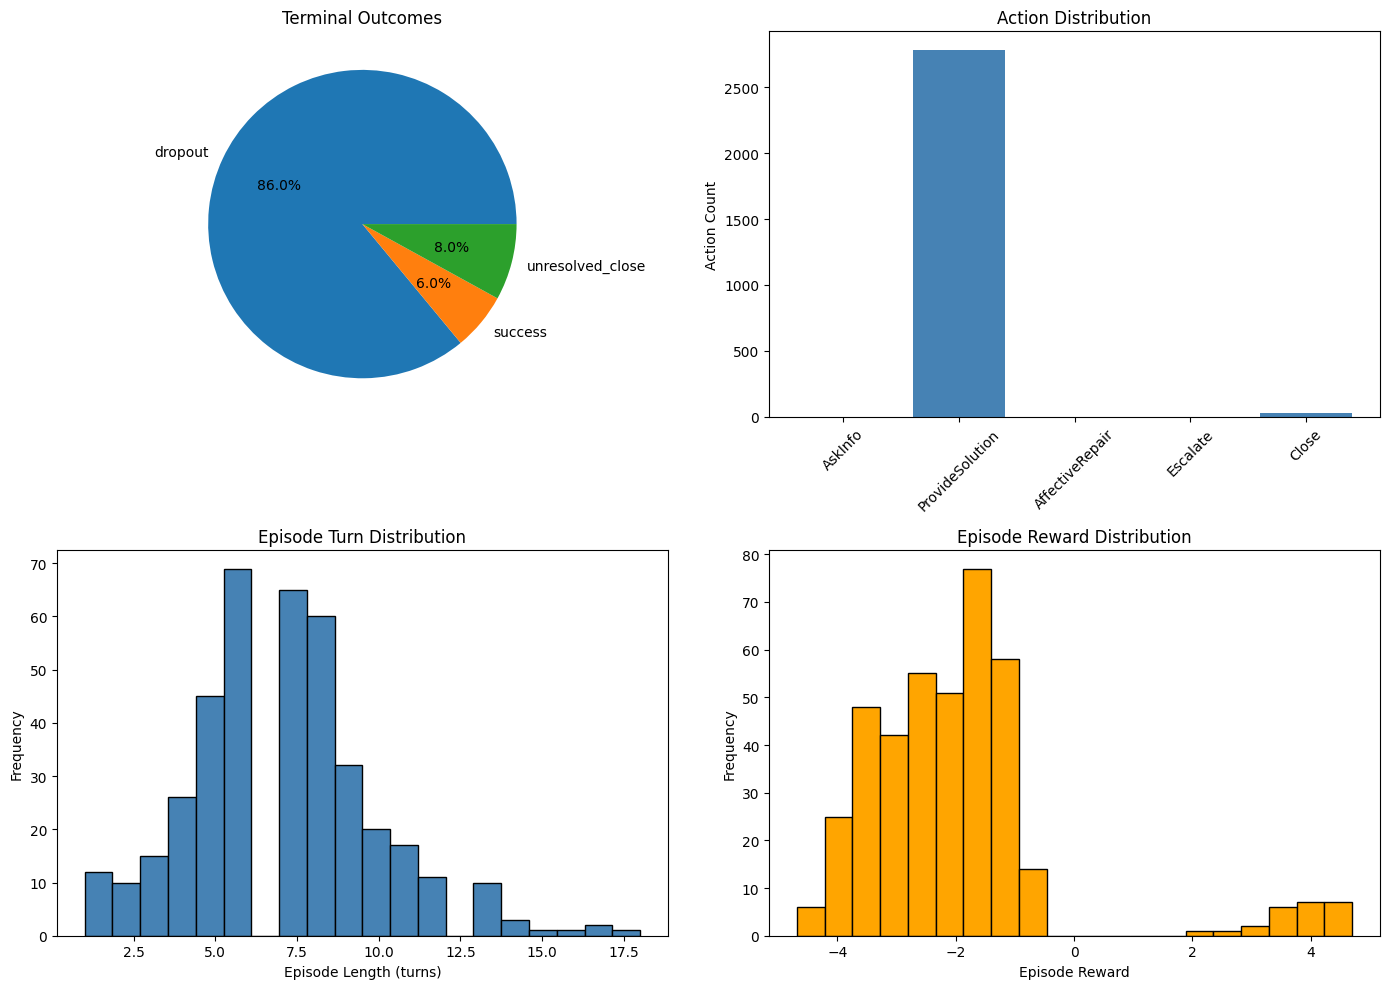

Visualizations complete.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Terminal outcomes pie
ax = axes[0, 0]
terminal_data = [terminal_types.get(tt, 0) for tt in sorted(terminal_types.keys())]
terminal_labels = sorted(terminal_types.keys())
ax.pie(terminal_data, labels=terminal_labels, autopct="%1.1f%%")
ax.set_title("Terminal Outcomes")

# Action distribution bar
ax = axes[0, 1]
action_data = [action_counts.get(a, 0) for a in range(5)]
action_labels = [ACTION_NAMES[a] for a in range(5)]
ax.bar(action_labels, action_data, color='steelblue')
ax.set_ylabel("Action Count")
ax.set_title("Action Distribution")
ax.tick_params(axis='x', rotation=45)

# Turn distribution
ax = axes[1, 0]
ax.hist(df_episodes['turns'], bins=20, color='steelblue', edgecolor='black')
ax.set_xlabel("Episode Length (turns)")
ax.set_ylabel("Frequency")
ax.set_title("Episode Turn Distribution")

# Reward distribution
ax = axes[1, 1]
ax.hist(df_episodes['reward'], bins=20, color='orange', edgecolor='black')
ax.set_xlabel("Episode Reward")
ax.set_ylabel("Frequency")
ax.set_title("Episode Reward Distribution")

plt.tight_layout()
plt.show()

print("Visualizations complete.")